# Notebook 8: Advanced Stacking Ensemble
---
Stacking Classifier with HistGradientBoosting, Random Forest, MLP as base estimators and Logistic Regression meta-model.

## Step 1: Feature Extraction Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

In [2]:
from scripts.data_utils import O4UHybridDataset, collate_fn

In [3]:
# ============================================
# Step 1: Setup & Data Loaders
# ============================================
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

from scripts.models import HybridFashionModel, FeatureExtractor
from scripts.config import DATA_PROCESSED_DIR, FEATURES_DIR as _FEATURES_DIR, SAVED_MODELS_DIR

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load phys_feature_cols from saved artifact — must match the trained model exactly
with open(SAVED_MODELS_DIR / "phys_feature_cols.json") as f:
    phys_feature_cols = json.load(f)
phys_dim_input = len(phys_feature_cols)
print(f"Physical feature dim: {phys_dim_input}")

FEATURES_DIR = str(_FEATURES_DIR)
df_train = pd.read_json(DATA_PROCESSED_DIR / "train_imputed_manifest.json")
df_val   = pd.read_json(DATA_PROCESSED_DIR / "val_imputed_manifest.json")

train_loader = DataLoader(O4UHybridDataset(df_train, FEATURES_DIR, phys_feature_cols),
                          batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(O4UHybridDataset(df_val,   FEATURES_DIR, phys_feature_cols),
                          batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)
print("DataLoaders ready.")

Device: mps
Physical feature dim: 99
 Checking/Caching 10080 visual features...
 Checking/Caching 2520 visual features...
DataLoaders ready.


In [4]:
# ============================================
# Load Model & Extract Features
# ============================================
model = HybridFashionModel(phys_input_dim=phys_dim_input).to(device)
checkpoint = torch.load(str(SAVED_MODELS_DIR / "best_hybrid_model.pth"), map_location=device, weights_only=True)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)
model.eval()

extractor = FeatureExtractor(model).to(device)
extractor.eval()


def extract_features(loader, desc):
    features_list, labels_list = [], []
    with torch.inference_mode():
        # collate_fn returns: visual_padded, visual_mask, phys_vecs, reg_labels, bin_labels
        for visual_feat, visual_mask, phys_vecs, reg_labels, bin_labels in tqdm(loader, desc=desc):
            visual_feat = visual_feat.to(device)
            visual_mask = visual_mask.to(device)
            phys_vecs   = phys_vecs.to(device)
            fused = extractor(visual_feat, visual_mask, phys_vecs)
            features_list.append(fused.cpu().numpy())
            labels_list.append(bin_labels.numpy())
    return np.vstack(features_list), np.concatenate(labels_list)


X_train, y_train = extract_features(train_loader, "Train")
X_val,   y_val   = extract_features(val_loader,   "Val")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

del model, extractor
import gc; gc.collect()

Train:   0%|          | 0/315 [00:00<?, ?it/s]

Val:   0%|          | 0/79 [00:00<?, ?it/s]

X_train: (10080, 256), X_val: (2520, 256)


48

## Step 2: Stacking Classifier Baseline

Training Stacking Classifier...

Stacking Baseline:
  Accuracy : 90.63%
  Precision: 88.48%
  Recall   : 96.45%
  F1-Score : 0.9229


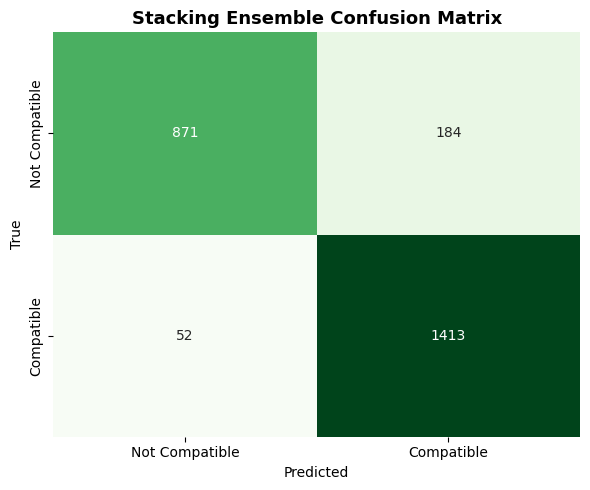

In [5]:
# ============================================
# Train Stacking Classifier (HGB + RF + MLP -> LogReg)
# ============================================
print("Training Stacking Classifier...")

base_estimators = [
    ("hgb", HistGradientBoostingClassifier(max_iter=100, max_depth=5, learning_rate=0.05, random_state=42)),
    ("rf",  RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=1)),
    ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, activation="relu", random_state=42)),
]

ensemble_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=500, random_state=42),
    cv=5, n_jobs=1,
)
ensemble_model.fit(X_train, y_train)

y_pred = ensemble_model.predict(X_val)
print(f"\nStacking Baseline:")
print(f"  Accuracy : {accuracy_score(y_val, y_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_val, y_pred, zero_division=0)*100:.2f}%")
print(f"  Recall   : {recall_score(y_val, y_pred, zero_division=0)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_val, y_pred, zero_division=0):.4f}")

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Not Compatible", "Compatible"],
            yticklabels=["Not Compatible", "Compatible"])
plt.title("Stacking Ensemble Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Step 3: Optuna Tuning
---
CV on training set only to prevent leakage.

### Search Space Rationale

| Hyperparameter | Range | Rationale |
|---|---|---|
| `hgb_lr` | [0.01, 0.2] log | Covers slow→moderate LR; above 0.2 risks overshooting. |
| `rf_depth` | [3, 15] | Consistent with NB05 depth range. |
| `logreg_c` | [0.01, 10.0] log | Strong→near-unregularized meta-learner. |

**Note:** `n_estimators` is fixed at 100 for RF (not tuned). In a stacking ensemble the RF is one of three base estimators, so tuning its tree count has low marginal benefit vs. search cost.

In [6]:
# ============================================
# Optuna Tuning (CV on train only)
# ============================================
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve

print("Running Optuna (30 trials, 3-fold CV on train)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective_stacking(trial):
    hgb_lr   = trial.suggest_float("hgb_lr",   0.01, 0.2,  log=True)
    rf_depth = trial.suggest_int(  "rf_depth",  3,    15)
    logreg_c = trial.suggest_float("logreg_c",  0.01, 10.0, log=True)

    base_estimators = [
        ("hgb", HistGradientBoostingClassifier(learning_rate=hgb_lr, max_iter=100, random_state=42)),
        ("rf",  RandomForestClassifier(max_depth=rf_depth, n_estimators=100, random_state=42, n_jobs=1)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, activation="relu", random_state=42)),
    ]
    clf = StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(C=logreg_c, max_iter=500, random_state=42),
        cv=3, n_jobs=1,
    )
    scores = cross_val_score(clf, X_train, y_train, cv=3, scoring="f1", n_jobs=1)
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective_stacking, n_trials=30, show_progress_bar=True)

print(f"\nBest params: {study.best_params}")
print(f"Best CV F1: {study.best_value:.4f}")

import json as _json
with open(str(SAVED_MODELS_DIR / "nb06_best_params.json"), "w") as _f:
    _json.dump(study.best_params, _f, indent=2)
print("Best params saved to saved_models/nb06_best_params.json")

Running Optuna (30 trials, 3-fold CV on train)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best params: {'hgb_lr': 0.01963815633730549, 'rf_depth': 8, 'logreg_c': 0.6282190012179933}
Best CV F1: 0.9374
Best params saved to saved_models/nb06_best_params.json


In [7]:
# ============================================
# Train Best Model + Threshold Optimization
# ============================================
best_hgb    = HistGradientBoostingClassifier(learning_rate=study.best_params["hgb_lr"], max_iter=100, random_state=42)
best_rf     = RandomForestClassifier(max_depth=study.best_params["rf_depth"], n_estimators=100, random_state=42, n_jobs=1)
best_mlp    = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, activation="relu", random_state=42)
best_logreg = LogisticRegression(C=study.best_params["logreg_c"], max_iter=500, random_state=42)

final_stacking = StackingClassifier(
    estimators=[("hgb", best_hgb), ("rf", best_rf), ("mlp", best_mlp)],
    final_estimator=best_logreg,
    cv=5, n_jobs=1,
)
final_stacking.fit(X_train, y_train)

y_probs = final_stacking.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_probs)
opt_thr = thresholds[np.argmax(tpr - fpr)]

print(f"Optimal Threshold (Youden's J): {opt_thr:.4f}")

y_pred_opt = (y_probs >= opt_thr).astype(int)
print(f"\nFinal Stacking Metrics (Optimized):")
print(f"  Accuracy  : {accuracy_score(y_val, y_pred_opt)*100:.2f}%")
print(f"  Precision : {precision_score(y_val, y_pred_opt, zero_division=0)*100:.2f}%")
print(f"  Recall    : {recall_score(y_val, y_pred_opt, zero_division=0)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_val, y_pred_opt, zero_division=0):.4f}")

Optimal Threshold (Youden's J): 0.1095

Final Stacking Metrics (Optimized):
  Accuracy  : 91.19%
  Precision : 87.74%
  Recall    : 98.63%
  F1-Score  : 0.9287
